In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data_entropy_binary.csv")
df = df.drop(columns=["Unnamed: 0"])

df.head()

# print(df["x_label"].value_counts())
# print(df["y_label"].value_counts())


,x_1,x_2,x_label,y_1,y_2,y_label
0,-0.204613,0.680304,0,-0.705065,2.161527,1
1,-1.151684,-1.312481,0,-0.180569,-0.945071,1
2,1.663691,1.135278,0,-0.751258,-1.684396,0
3,-0.612010,-0.380869,0,-1.365583,0.170444,1
4,1.052268,0.276804,0,0.280257,1.111095,1


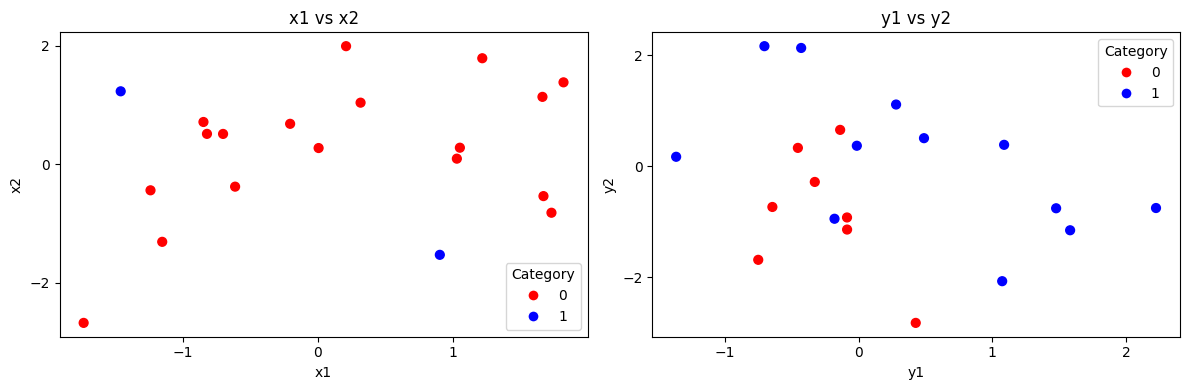

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {0: "red", 1: "blue"}

x_point_colors = df["x_label"].map(color_map)

axes[0].scatter(df["x_1"], df["x_2"], c=x_point_colors, s=40)
axes[0].set_title("x1 vs x2")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xticks([-1, 0, 1])
axes[0].set_yticks([-2, 0, 2])

y_point_colors = df["y_label"].map(color_map)

axes[1].scatter(df["y_1"], df["y_2"], c=y_point_colors, s=40)
axes[1].set_title("y1 vs y2")
axes[1].set_xlabel("y1")
axes[1].set_ylabel("y2")
axes[1].set_xticks([-1, 0, 1, 2])
axes[1].set_yticks([-2, 0, 2])

legend_items = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='1')
]

axes[0].legend(handles=legend_items, title="Category")
axes[1].legend(handles=legend_items, title="Category")

plt.tight_layout()
plt.show()

In [6]:
from collections import Counter

def compute_probabilities(values):
    label_counts = Counter(values)
    num_elements = sum(label_counts.values())

    probs = {key: value / num_elements for key, value in label_counts.items()}

    return probs

In [7]:
y_label_probs = compute_probabilities(df["y_label"])
x_label_probs = compute_probabilities(df["x_label"])
print(x_label_probs)
print(y_label_probs)

{0: 0.9, 1: 0.1}
{1: 0.6, 0: 0.4}


In [14]:
import math

def compute_entropy(prob_dict):
    h = 0

    for prob in prob_dict.values():
        if prob != 0:
            h -= prob * math.log2(prob)

    return h


def report_entropy(data, var_name):
    probability_distribution = compute_probabilities(data)
    h_value = compute_entropy(probability_distribution)
    h_max = math.log2(len(probability_distribution))

    print(f"Entropy for {var_name}: {h_value:.4f}")
    print(f"Maximum possible entropy for {var_name}: {h_max:.4f}\n")


report_entropy(df["x_label"], "X")
report_entropy(df["y_label"], "Y")

Entropy for X: 0.4690
Maximum possible entropy for X: 1.0000

Entropy for Y: 0.9710
Maximum possible entropy for Y: 1.0000



In [12]:
df2 = pd.read_csv("data_entropy_multi.csv")
df2 = df2.drop(columns=["Unnamed: 0"])
df2.head()


,x_1,x_2,x_label,y_1,y_2,y_label
0,-0.588268,0.553082,3,0.130028,0.383891,0
1,0.840389,-0.573494,2,-0.116797,-1.999156,0
2,-0.079862,0.541607,3,-0.932190,0.665359,0
3,-0.698488,-0.971328,3,1.131281,0.670446,0
4,0.961912,-0.054403,3,-1.047647,-0.692437,0


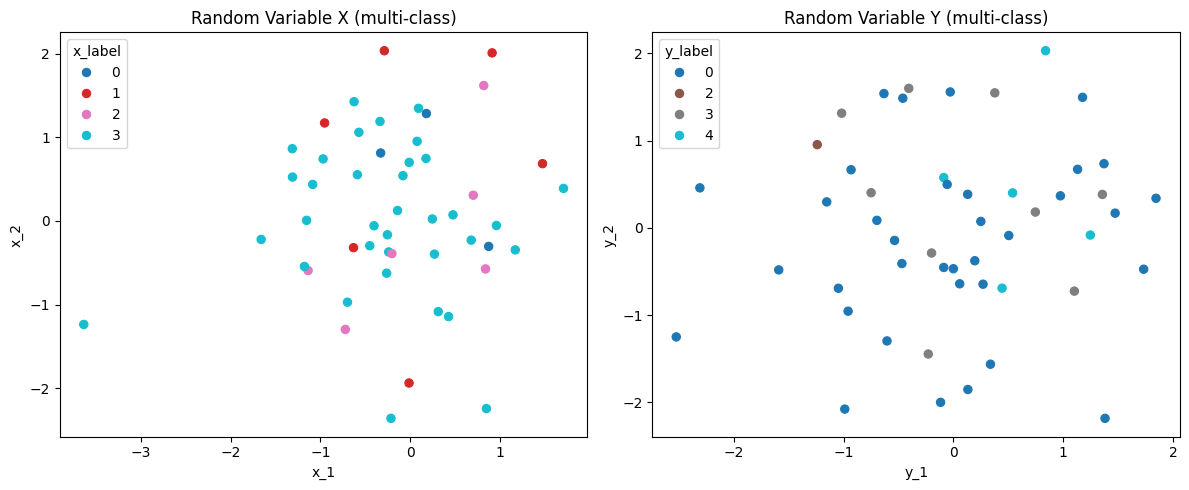

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_x = plt.scatter(
    df2["x_1"],
    df2["x_2"],
    c=df2["x_label"],
    cmap="tab10",
    linewidths=0.8
)

plt.title("Random Variable X (multi-class)")
plt.xlabel("x_1")
plt.ylabel("x_2")

legend_x = plot_x.legend_elements()
plt.legend(*legend_x, title="x_label", loc="upper left")

plt.subplot(1, 2, 2)
plot_y = plt.scatter(
    df2["y_1"],
    df2["y_2"],
    c=df2["y_label"],
    cmap="tab10",
    linewidths=0.8
)

plt.title("Random Variable Y (multi-class)")
plt.xlabel("y_1")
plt.ylabel("y_2")

legend_y = plot_y.legend_elements()
plt.legend(*legend_y, title="y_label", loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
report_entropy(df2["x_label"], "X")
report_entropy(df2["y_label"], "Y")
print("""More labels increase the possible maximum entropy,
       but the actual entropy is only high when those labels
       occur with similar probabilities.""")

Entropy for X: 1.3379
Maximum possible entropy for X: 2.0000

Entropy for Y: 1.2506
Maximum possible entropy for Y: 2.0000



In [16]:
print("Entropy increases with an increase in number of classes, \nBecause greater number unique labels for a variable the uncertainty increases.")

Entropy increases with an increase in number of classes, 
Because greater number unique labels for a variable the uncertainty increases.


# **Ex2**

In [23]:
import numpy as np
def mahalanobis_distance(x, mean, cov):
    delta = x - mean
    inv_cov = np.linalg.inv(cov)
    return np.sqrt(delta.T @ inv_cov @ delta)

In [14]:
df3 = pd.read_csv("data_mdistance.csv")
df3 = df3.drop(columns=["Unnamed: 0"])
df3.head()

,x_1,x_2
0,0.841347,3.664968
1,1.047163,2.654745
2,2.187950,2.284721
3,2.310741,3.712085
4,2.686888,3.229162


In [15]:
means = df3.mean()
cov_matrix = df3.cov()
correlation_matrix = df3.corr(method='pearson')

In [16]:
print("mean:")
print(means)

mean:
x_1    1.030928
x_2    2.923798
dtype: float64


In [17]:
print("\ncovariance matrix:-")
print(cov_matrix)


covariance matrix:-
          x_1       x_2
x_1  1.911777 -0.803587
x_2 -0.803587  0.844413


In [18]:
print("Pearson Correlation:")
print(correlation_matrix)

Pearson Correlation:
          x_1       x_2
x_1  1.000000 -0.632465
x_2 -0.632465  1.000000


In [19]:
def euclidean_distance(x, mean):
  dis = np.sqrt(np.sum((x - mean) ** 2))
  return dis

In [21]:
points_df = pd.read_csv("data_mdistance_points.csv")
points_df = points_df.drop(columns=["Unnamed: 0"])
points_df.head()

,px,py
0,0.680916,2.803206
1,3.436862,3.096334
2,-1.486187,2.229595
3,0.810948,3.671467
4,0.356183,2.253676


In [24]:
for index, values in points_df.iterrows():
    current_point = values.to_numpy()

    euclidean_result = euclidean_distance(current_point, means)
    mahalanobis_result = mahalanobis_distance(current_point, means, cov_matrix)

    print(
        f"Point x{index + 1}: "
        f"Mahalanobis Distance = {mahalanobis_result:.4f},"
        f"Euclidean Distance = {euclidean_result:.4f}, "

    )

Point x1: Mahalanobis Distance = 0.4534,Euclidean Distance = 0.3702, 
Point x2: Mahalanobis Distance = 2.4071,Euclidean Distance = 2.4121, 
Point x3: Mahalanobis Distance = 3.0618,Euclidean Distance = 2.6111, 
Point x4: Mahalanobis Distance = 0.9342,Euclidean Distance = 0.7794, 
Point x5: Mahalanobis Distance = 1.4260,Euclidean Distance = 0.9510, 


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def ax_ellipse(mean, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = mean
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

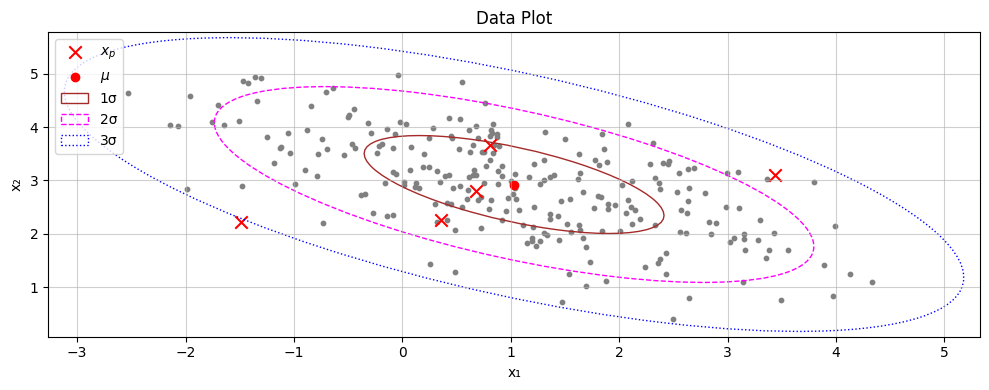

In [36]:
data_points = df3[["x_1", "x_2"]]
sample_points = points_df[["px", "py"]]

center = data_points.mean().to_numpy()
cov_matrix = data_points.cov().to_numpy()

plt.figure(figsize=(10, 4))
axis = plt.gca()


axis.scatter(data_points["x_1"], data_points["x_2"], c="gray", s=10)


axis.scatter(sample_points["px"], sample_points["py"],
             c="red", marker="x", s=80, label=r"$x_p$")


axis.scatter(center[0], center[1],
             c="red", marker="o", label=r"$\mu$")

ax_ellipse(center, cov_matrix, axis, n_std=1.0, edgecolor="brown", label="1σ")
ax_ellipse(center, cov_matrix, axis, n_std=2.0, edgecolor="magenta", linestyle="--", label="2σ")
ax_ellipse(center, cov_matrix, axis, n_std=3.0, edgecolor="blue", linestyle=":", label="3σ")

axis.set_title("Data Plot")
axis.set_xlabel("x₁")
axis.set_ylabel("x₂")
axis.legend(loc="upper left")
axis.grid(alpha=0.6)

plt.tight_layout()
plt.show()

In [38]:
print("Mahalanobis distance considers correlations between variables and accounts for the scale of the data, making it more reliable when variances differ or features are correlated. In contrast, Euclidean distance treats all dimensions equally and does not adapt to such variations, which can lead to misleading results when data is unevenly scaled or correlated.")

Mahalanobis distance considers correlations between variables and accounts for the scale of the data, making it more reliable when variances differ or features are correlated. In contrast, Euclidean distance treats all dimensions equally and does not adapt to such variations, which can lead to misleading results when data is unevenly scaled or correlated.


# **Ex3**

In [39]:
print("What are the mathematical properties of KL divergence? List and explain the fundamental properties.")
print("Answer:-")
print("-> Non-negativity: This property, known as Gibbs' inequality, implies that KL divergence is always non-negative and is zero if \n   and only if P = Q almost everywhere. It measures how much information is lost when approximating P with Q.")
print("-> Asymmetry (Non-symmetry):KL divergence is not symmetric, meaning it does not satisfy the properties of a distance metric")
print("-> Additivity: If P and Q are distributions over joint distributions P(X,Y) and Q(X,Y). \n   This property shows that the KL divergence of a joint distribution can be broken down into the sum of the KL divergences of \n   the marginal distributions.")

What are the mathematical properties of KL divergence? List and explain the fundamental properties.
Answer:-
-> Non-negativity: This property, known as Gibbs' inequality, implies that KL divergence is always non-negative and is zero if 
   and only if P = Q almost everywhere. It measures how much information is lost when approximating P with Q.
-> Asymmetry (Non-symmetry):KL divergence is not symmetric, meaning it does not satisfy the properties of a distance metric
-> Additivity: If P and Q are distributions over joint distributions P(X,Y) and Q(X,Y). 
   This property shows that the KL divergence of a joint distribution can be broken down into the sum of the KL divergences of 
   the marginal distributions.


In [40]:
p = np.array([0.05, 0.20, 0.40, 0.20, 0.15])
q = np.array([0.10, 0.60, 0.05, 0.15, 0.10])


def kl_divergence(p, q):
    epsilon = 1e-10
    q_safe = np.maximum(q, epsilon) # to avoid zero error
    return np.sum(p * np.log(p / q_safe))


kl_p_q = kl_divergence(p, q)
kl_q_p = kl_divergence(q, p)


print(f"D_KL(p || q) = {kl_p_q}")
print(f"D_KL(q || p) = {kl_q_p}")

D_KL(p || q) = 0.6957529806168959
D_KL(q || p) = 0.5408111924942849
